# CSCI8350 Graduate Project
Emily Uehling and Troy Gilmore

Rice Paddy Yield Dataset and Modeling

Week 3 - Clustering

## Import Packages

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## Load and Set up Preprocess Pipeline

In [2]:
# ── Data Loading ──────────────────────────────────────────────────────────────
data = Path("Data/paddydataset.csv")
df = pd.read_csv(data)
df.columns = df.columns.str.strip()

# ── Create constants, variables ────────────────────────────────────────────────
random_state = 42

# ── Build Modeling Dataset ────────────────────────────────────────────────────
df_for_clustering = df.copy()

# ──  Drop duplicate rows ────────────────────────────────────────────────────
df_for_clustering = df_for_clustering.drop_duplicates()
print("Shape after dropping duplicates:", df_for_clustering.shape)

# ── Create yield per hectare, drop raw yield and correlated columns ───────────
df_for_clustering['Yield per Hectare'] = df_for_clustering['Paddy yield(in Kg)'] / df_for_clustering['Hectares']
df_for_clustering = df_for_clustering.drop(columns=[
    'LP_Mainfield(in Tonnes)',
    'LP_nurseryarea(in Tonnes)',
    'Nursery area (Cents)',
    'Paddy yield(in Kg)'
])

# ── Identify and print lists of numeric and categorical features ───────────
numeric_features = df_for_clustering.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df_for_clustering.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# ── Set up pipeline for encoding, drop features with variance = 0.0 ───────────
preprocessor = Pipeline(steps=[
    ("column_transform", ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ])),
    ("var_threshold", VarianceThreshold(threshold=0.0))
])

print("Preprocessing pipeline:", preprocessor)

Shape after dropping duplicates: (2338, 45)
Preprocessing pipeline: Pipeline(steps=[('column_transform',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Agriblock', 'Variety',
                                                   'Soil Types', 'Nursery',
                                                   'Wind Direction_D1_D30',
                                                   'Wind Direction_D31_D60',
                                                   'Wind Direction_D61_D90',
                                                   'Wind Direction_D91_D120']),
                                                 ('num', 'passthrough',
                                                  ['Hectares',
                                                   'Seedrate(in Kg)',
                                                   'DAP_20days',
                 

## Explore PCA for Reducing Dimensionality

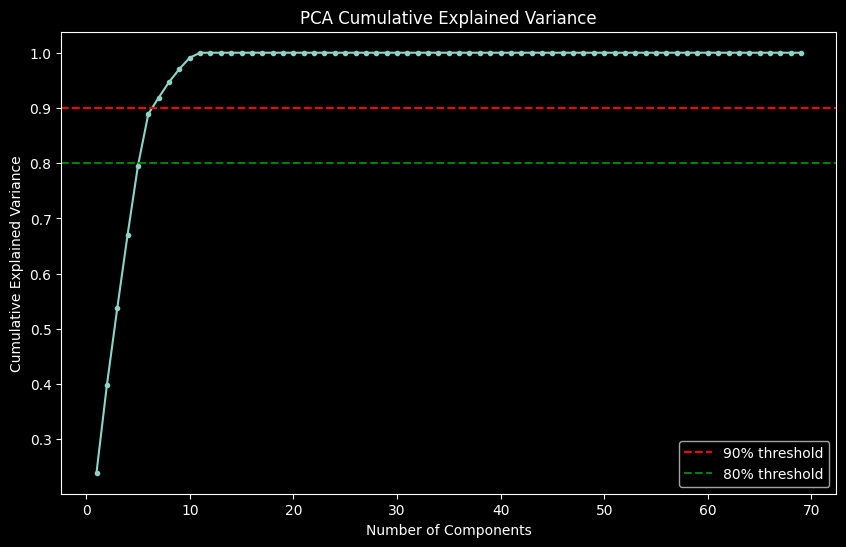

Components needed for 80% variance: 6
Components needed for 90% variance: 7


In [3]:
# ── Cumulative Explained Variance Plot ────────────────────────────────────────
# First preprocess the data
X_preprocessed = preprocessor.fit_transform(df_for_clustering)

# Scale before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_preprocessed.toarray() if hasattr(X_preprocessed, 'toarray') else X_preprocessed)

# Fit PCA with all components
pca_full = PCA(random_state=random_state)
pca_full.fit(X_scaled)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.axhline(y=0.80, color='g', linestyle='--', label='80% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.show()

# Print exact number of components needed
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 80% variance: {n_components_80}")
print(f"Components needed for 90% variance: {n_components_90}")

## Create Transformed Dataset using PCA that Preserves 90% Variance

In [4]:
# ── Set up pipeline for scaler and PCA to reduce dimensionality ───────────
scaler_with_PCA = Pipeline(steps=[('scaler', StandardScaler()),
                                  ('pca', PCA(n_components=7, random_state=random_state))]) #changed to 7

print("Scaling and PCA pipeline:", scaler_with_PCA)

# ── Create transformed dataset for later use with silhouette ────────────────
print("Created transformed dataset after scaler and PCA, but prior to K-means.")
X_transformed = scaler_with_PCA.fit_transform(X_preprocessed)
print(X_transformed)

Scaling and PCA pipeline: Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=7, random_state=42))])
Created transformed dataset after scaler and PCA, but prior to K-means.
[[-4.42571693 -1.45300619  4.77137904 ... -4.70059273  2.81279894
   2.10067127]
 [-5.60385733 -3.17978249  0.57285813 ... -0.01691598 -2.42803748
  -2.02203077]
 [ 5.63164541 -1.30215013  0.77745509 ... -5.74579166 -2.15314327
   2.14819963]
 ...
 [ 1.57492935  2.55421037 -6.45932265 ...  2.78938717  4.34438736
  -0.16841455]
 [ 3.48488299 -2.10056906 -0.71709797 ...  4.99968366  0.0838446
  -2.00193162]
 [-1.3053906   7.10015142 -1.86202368 ...  2.07538632 -2.27612742
  -2.04494198]]


## Set up K-means Pipeline and Do a Test Fit

In [5]:
# ── Set up pipeline for k-means ─────────────────────────────────────────────
k_means = Pipeline(steps=[('kmeans', KMeans(n_clusters=3,
                                            init='k-means++',
                                            n_init=10,
                                            max_iter=300,
                                            tol=0.0001,
                                            random_state=random_state,
                                            algorithm='elkan')
                           )])
print("K-Means pipeline:", k_means)

# ── Set up full pipeline for k-means ─────────────────────────────────────────────
k_means_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                   ("scaler_PCA", scaler_with_PCA),
                                   ("kmeans", k_means)
                                   ])

# ── Test fit k-means to check for errors ────────────────────────────────────────────────────────────
k_means_pipeline.fit(df_for_clustering)

K-Means pipeline: Pipeline(steps=[('kmeans',
                 KMeans(algorithm='elkan', n_clusters=3, n_init=10,
                        random_state=42))])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler_PCA', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transform', ...), ('var_threshold', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transforme

## Use Inertia and Silhouette Score to Choose Optimal K for K-means

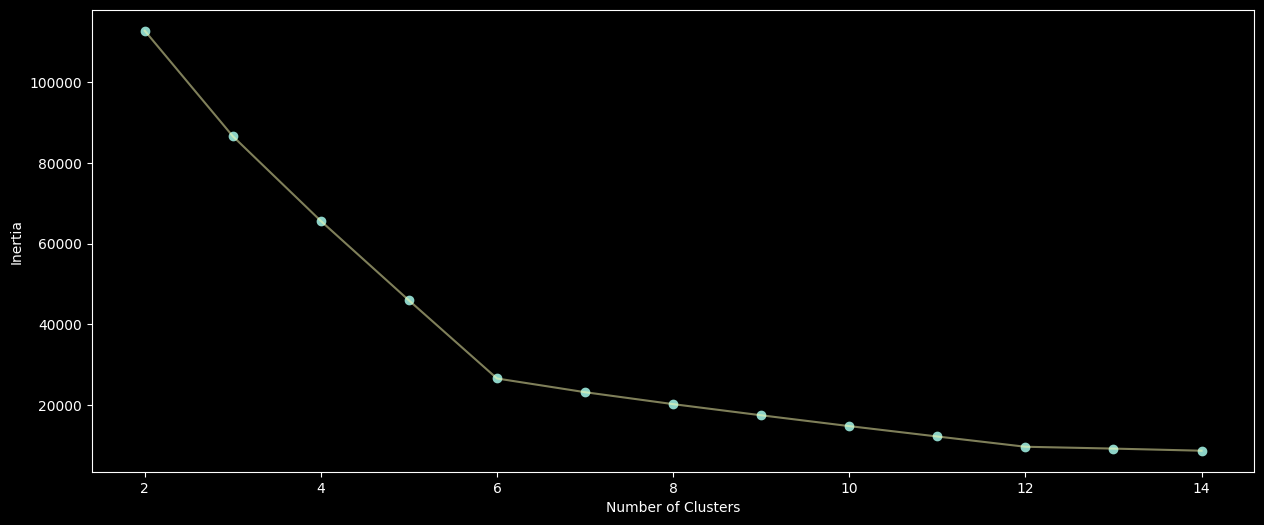

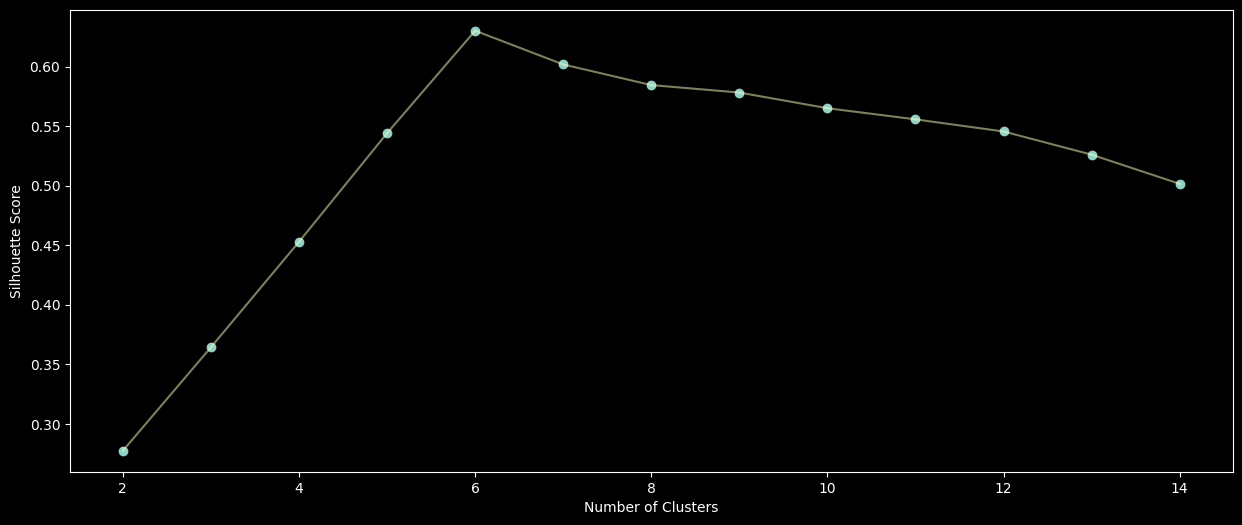

In [6]:
# ── Deciding K value ───────────────────────────────────────────────────────────────
inertia = []
silhouette_scores = []

# Set range of K to try
# NOTE: expect algorithm warnings (lloyd instead of elkan)
#   and silhouette warnings if range includes 1 cluster
k_range = range(2, 15)

for k in k_range:
    # ── Full pipeline for k-means ──
    pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                       ("scaler_PCA", scaler_with_PCA),
                                       ("kmeans", KMeans(n_clusters=k,
                                                         init='k-means++',
                                                         n_init=10,
                                                         max_iter=300,
                                                         tol=0.0001,
                                                         random_state=random_state,
                                                         algorithm='elkan')
                                        )])
    pipeline.fit(df_for_clustering)
    inertia.append(pipeline.named_steps["kmeans"].inertia_)
# NOTE: Use the preprocessed data (after PCA) as input to the silhouette_score function
    score = silhouette_score(X_transformed, pipeline.named_steps["kmeans"].labels_)
    silhouette_scores.append(score)

# ── Plot Inertia ─────────────────────────────────────────────────────────
plt.figure(1, figsize=(15, 6))
plt.plot(k_range, inertia, 'o')
plt.plot(k_range, inertia, '-', alpha=0.5)
plt.xlabel('Number of Clusters'), plt.ylabel('Inertia')
plt.show()

# ── Plot Silhouette Scores ───────────────────────────────────────────────
# More complex example at https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
plt.figure(1, figsize=(15, 6))
plt.plot(k_range, silhouette_scores, 'o')
plt.plot(k_range, silhouette_scores, '-', alpha=0.5)
plt.xlabel('Number of Clusters'), plt.ylabel('Silhouette Score')
plt.show()

## Final K-means Pipeline
- One-hot encoding
- Standard Scaler
- PCA with 90% of variance preserved
- Optimal K = 6, based on elbow and silhouette

In [7]:
# ── Final pipeline for k-means ──
final_k = 6
final_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                   ("scaler_PCA", scaler_with_PCA),
                                   ("kmeans", KMeans(n_clusters=final_k,
                                                     init='k-means++',
                                                     n_init=10,
                                                     max_iter=300,
                                                     tol=0.0001,
                                                     random_state=random_state,
                                                     algorithm='lloyd')
                                    )])
final_pipeline.fit(df_for_clustering)

#  ── Review PCA values ──────────────────────────────────────────────────
# Since scaler_PCA is a pipeline in a pipeline, we have to drill down
#   from scaler_PCA --> pca to get values such as number of components and explained variance
#   see "Attributes" section of https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
pca = final_pipeline.named_steps["scaler_PCA"].named_steps["pca"]
pca_comp = pca.n_components_
pca_explained_variance = pca.explained_variance_ratio_.sum()
print("Number of PCA components:", pca_comp)
print("PCA explained variance:", pca_explained_variance)

Number of PCA components: 7
PCA explained variance: 0.9187007019394591


# Visualize Results using PCA

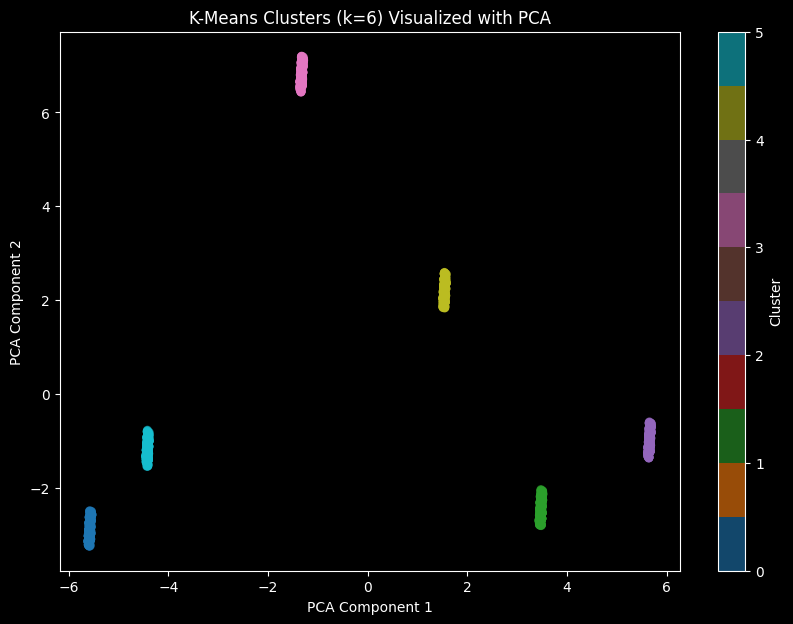

In [8]:
# Potential source of code for plotting results with PCA
# https://www.geeksforgeeks.org/machine-learning/kmeans-clustering-and-pca-on-wine-dataset/
#  ── Cluster Visualization Using PCA ──────────────────────────────────────────────────
# Get cluster labels from the pipeline
cluster_labels = final_pipeline.predict(df_for_clustering)

# Use first 2 PCA components for visual
pca_2d = Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2, random_state=random_state))])

X_2d = pca_2d.fit_transform(X_preprocessed)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'K-Means Clusters (k={final_k}) Visualized with PCA')
plt.show()

## Cluster Interpretation
Cluster visualization shows well separated, pill-shaped clusters which suggests the groupings are being driven by categorical variables. To confirm, we look at the average numeric feature values and the most common categorical values within each cluster.

In [11]:
df_for_clustering['Cluster'] = cluster_labels

print("\n=== Cluster Sizes ===")
print(df_for_clustering['Cluster'].value_counts().sort_index())

print("\n=== Cluster Profiles (Numeric Features) ===")
print(df_for_clustering.groupby('Cluster')[numeric_features].mean().round(2))

print("\n=== Cluster Profiles (Categorical Features) ===")
for col in categorical_features:
    print(f"\n-- {col} --")
    print(df_for_clustering.groupby('Cluster')[col].agg(lambda x: x.value_counts().index[0]))


=== Cluster Sizes ===
Cluster
0    401
1    502
2    360
3    358
4    353
5    364
Name: count, dtype: int64

=== Cluster Profiles (Numeric Features) ===
         Hectares  Seedrate(in Kg)  DAP_20days  Weed28D_thiobencarb  \
Cluster                                                               
0            3.73            93.20      149.13                 7.46   
1            3.81            95.27      152.43                 7.62   
2            3.67            91.74      146.78                 7.34   
3            3.72            93.09      148.94                 7.45   
4            3.71            92.63      148.22                 7.41   
5            3.75            93.75      150.00                 7.50   

         Urea_40Days  Potassh_50Days  Micronutrients_70Days  \
Cluster                                                       
0             101.15           38.70                  55.92   
1             103.39           39.56                  57.16   
2              99.55   

## Cluster Descriptions
Based on the cluster profiles, each cluster maps primarily to a distinct geographic
region (Agriblock). Numeric features including Yield per Hectare show minimal
variation across clusters, confirming that the clusters represent geographic
farming segments rather than meaningful differences in yield performance.
This is a direct consequence of the narrow yield range in the dataset.

In [10]:
cluster_descriptions = {
    0: "Kurinjipadi region — ponmani variety, NW wind pattern",
    1: "Sankarapuram region — delux ponni variety, SSE wind pattern",
    2: "Panruti region — delux ponni variety, ENE wind pattern",
    3: "Chinnasalem region — ponmani variety, E wind pattern",
    4: "Kallakurichi region — ponmani variety, W wind pattern",
    5: "Cuddalore region — delux ponni variety, SW wind pattern"
}

print("\n=== Cluster Descriptions ===")
for cluster, description in cluster_descriptions.items():
    print(f"Cluster {cluster}: {description}")


=== Cluster Descriptions ===
Cluster 0: Kurinjipadi region — ponmani variety, NW wind pattern
Cluster 1: Sankarapuram region — delux ponni variety, SSE wind pattern
Cluster 2: Panruti region — delux ponni variety, ENE wind pattern
Cluster 3: Chinnasalem region — ponmani variety, E wind pattern
Cluster 4: Kallakurichi region — ponmani variety, W wind pattern
Cluster 5: Cuddalore region — delux ponni variety, SW wind pattern


## Numeric-Only Clustering
Since the initial clustering was dominated by categorical variables(Agriblock)
we repeated the clustering using numeric features only to see if yield-based patterns would emerge.

Unfortunately the result was similar. Yield per Hectare remained nearly identical across all clusters
and the silhouette scores continued climbing without plateauing, indicating no strong natural cluster
structure exists in the numeric data either.

This is consistent with our classification findings. The yield values span a narrow range of roughly
1,000 kg/hectare, making meaningful separation difficult regardless of the approach. The dominant
pattern in this dataset is geographic segmentation rather than yield performance segmentation.